# Tutorial

This notebook presents a complete example of how to use the `sciml` package to solve, with a PINN, the one-dimensional steady-state advection–diffusion problem parametrized by the Peclet number.

**Problem definition:**

$$
    \begin{cases}
        u_{xx} - Pe u_x = 0,
        & (x, Pe) \in [0, 1] \times [Pe_{\min}, Pe_{\max}], \\
        u(0, Pe) = 1,
        & Pe \in [Pe_{\min}, Pe_{\max}], \\
        u(1, Pe) = 0,
        & Pe \in [Pe_{\min}, Pe_{\max}].
    \end{cases}
$$

**Analytical solution:**

$$
    u(x, Pe) = \frac{1 - \exp(Pe(x - 1))}{1 - \exp(-Pe)}.
$$

## 1. Packages
---

In [11]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import numpy as np
import torch
import matplotlib.pyplot as plt

from pathlib import Path

from sciml.core import ModelBase, Objective, Validation

from sciml.strategies import Strategy
from sciml.losses import Supervised, Residual
from sciml.metrics import MeanSquaredError, MaxError
from sciml.samplers import LatinHypercube, Scaler
from sciml.trainers import Trainer
from sciml.callbacks import Logger
from sciml.utils import initialization

## 2. Parameters and settings
---

In [12]:
# Set random seeds for reproducibility
torch.manual_seed(1234)
np.random.seed(1234)

# Define device and data type
DEVICE = "cpu"
DTYPE = torch.float32

# Define results directory
RESULTS_DIR = Path("./results/standard/")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Define neural network
INPUT_DIM = 2
OUTPUT_DIM = 1
HIDDEN_LAYERS = [10, 10]

# Define problem parameters
PE_MIN = 0.0
PE_MAX = 10.0

# Define training parameters
N_RESIDUAL = 2000
N_BOUNDARY = 500
N_VALIDATION = 5000

BATCH_RESIDUAL = N_RESIDUAL
BATCH_BOUNDARY = N_BOUNDARY
BATCH_VALIDATION = 5000

ITERATIONS = 1000

## 3. Analytical solution
---

In [13]:
# Define the analytical solution of the advection-diffusion equation
def solution(x: np.ndarray, peclet: np.ndarray) -> np.ndarray:
    """Compute the analytical solution of the advection-diffusion equation."""
    eps: float = 1e-3
    peclet = peclet.clip(min=eps)
    return (1 - np.exp(peclet * (x - 1))) / (1 - np.exp(-peclet))

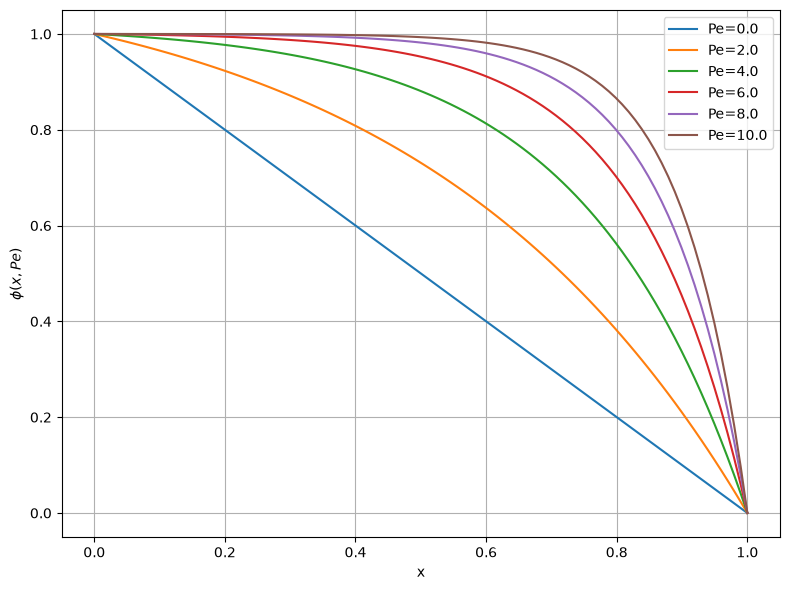

In [14]:
# Define the spatial and parameter domains
x = np.linspace(0, 1, 100)
peclet = np.arange(0, 12, 2)

# Plot the analytical solution
plt.figure(figsize=(8, 6))
for p in peclet:
    p = np.full_like(x, p)
    u_ref = solution(x, p)
    plt.plot(x, u_ref, label=f"Pe={p[0]:.1f}")

plt.ylabel(r"$\phi(x, Pe)$")
plt.xlabel("x")
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

## 4. Components
---

### 4.1. Model

In [15]:
# Define the neural network architecture
class MLP(torch.nn.Module):
    """Simple fully-connected neural network."""

    def __init__(
            self,
            input_dim: int,
            output_dim: int,
            hidden_layers: tuple[int, ...] = (64, 64, 64),
            activation: type[torch.nn.Module] = torch.nn.Tanh,
        ) -> None:
        super().__init__()

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(torch.nn.Linear(previous_dim, hidden_dim))
            layers.append(activation())
            previous_dim = hidden_dim

        layers.append(torch.nn.Linear(previous_dim, output_dim))

        self.net = torch.nn.Sequential(*layers)

        return

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [16]:
# Define the neural network
class Model(ModelBase):

    def __init__(self):
        self.network = MLP(
            input_dim=INPUT_DIM,
            output_dim=OUTPUT_DIM,
            hidden_layers=HIDDEN_LAYERS,
        ).to(device=DEVICE, dtype=DTYPE)
        self.network.apply(initialization.xavier_normal)
        return
    
    def compute(self, context) -> None:
        context.requires_grad("x")
        context["phi"] = self.network(torch.cat([context["x"], context["peclet"]], dim=1))
        return

model = Model()

### 4.2. Losses

In [17]:
# Define the residual loss
class ResidualLoss(Residual):
    """Residual loss for phi_xx - Pe * phi_x = 0."""

    def residual(self, context) -> torch.Tensor:
        
        # Compute the first and second derivatives of phi with respect to x
        phi_x, key = context.partial("phi", "x")
        phi_xx, _ = context.partial(key, "x")

        # Scale peclet
        peclet = context["peclet"] * PE_MAX

        return (phi_xx - peclet * phi_x) / (1 + peclet)

# Define the losses
residual_loss = ResidualLoss(
    name="residual",
    weight=1.0,
)

left_bc_loss = Supervised(
    name="left_bc",
    weight=10.0,
    input_keys=["x", "peclet"],
    target_keys=["phi"],
)

right_bc_loss = Supervised(
    name="right_bc",
    weight=10.0,
    input_keys=["x", "peclet"],
    target_keys=["phi"],
)

### 4.3. Samplers

In [18]:
# Define the samplers
residual_sampler = LatinHypercube(
    dim=2,
    num_points=N_RESIDUAL,
    batch_size=BATCH_RESIDUAL,
    input_keys=["x", "peclet"],
    device=DEVICE,
    dtype=DTYPE,
)

left_bc_sampler = LatinHypercube(
    dim=2,
    num_points=N_BOUNDARY,
    batch_size=BATCH_BOUNDARY,
    insertions=[(0, 0.0)],
    input_keys=["x", "peclet"],
    target_keys=["phi"],
    target_fn=solution,
    device=DEVICE,
    dtype=DTYPE,
)

right_bc_sampler = LatinHypercube(
    dim=2,
    num_points=N_BOUNDARY,
    batch_size=BATCH_BOUNDARY,
    insertions=[(0, 1.0)],
    input_keys=["x", "peclet"],
    target_keys=["phi"],
    target_fn=solution,
    device=DEVICE,
    dtype=DTYPE,
)

validation_sampler = LatinHypercube(
    dim=2,
    num_points=N_BOUNDARY,
    batch_size=BATCH_BOUNDARY,
    input_keys=["x", "peclet"],
    target_keys=["phi"],
    target_fn=solution,
    device=DEVICE,
    dtype=DTYPE,
)

## 5. Training
---

Settings

In [19]:
# Define the trainer
trainer = Trainer(
    model=model,
    objectives=[
        Objective(
            sampler=residual_sampler,
            losses=[residual_loss],
        ),
        Objective(
            sampler=left_bc_sampler,
            losses=[left_bc_loss],
        ),
        Objective(
            sampler=right_bc_sampler,
            losses=[right_bc_loss],
        )
    ],
    strategies=[
        Strategy(
            optimizer=torch.optim.Adam(model.network.parameters()),
        )
    ],
    logger=Logger(str(RESULTS_DIR)),
    validations=[
        Validation(
            "interpolation",
            frequency=100,
            sampler=validation_sampler,
            losses=[
                Supervised(
                    name="mse-interpolation",
                    input_keys=["x", "peclet"],
                    target_keys=["phi"],
                    reduction=MeanSquaredError()
                )
            ]
        )
    ]
)

Optimize

In [20]:
trainer.fit(num_iterations=ITERATIONS, verbose=True, verbose_frequency=50)

     Iteration       training       residual        left_bc       right_bc mse-interpola.
-------------- -------------- -------------- -------------- -------------- --------------
             1   8.876130e+00   1.925804e-02   2.750065e-01   6.106806e-01   3.754985e-01
            50   2.062657e+00   1.405187e-01   9.844338e-02   9.377041e-02              -
           100   1.950659e+00   1.058134e-01   9.445895e-02   9.002563e-02   5.001492e-02
           150   1.887755e+00   1.188199e-01   8.964585e-02   8.724768e-02              -
           200   1.850207e+00   1.268404e-01   8.672851e-02   8.560818e-02   4.504384e-02
           250   1.833062e+00   1.317806e-01   8.526620e-02   8.486193e-02              -
           300   1.826258e+00   1.336795e-01   8.467631e-02   8.458157e-02   4.373854e-02
           350   1.822887e+00   1.334704e-01   8.446245e-02   8.447926e-02              -
           400   1.820392e+00   1.322088e-01   8.438300e-02   8.443532e-02   4.352601e-02
          

## 6. Post-process
---

### 6.1. Losses and metrics history

In [21]:
history = trainer.logger.to_dataframe("training")

print(history)

     iteration  Objective function  residual   left_bc  right_bc
0            1            8.876130  0.019258  0.275007  0.610681
1            2            8.502374  0.021874  0.266403  0.581647
2            3            8.139660  0.024685  0.258024  0.553474
3            4            7.788190  0.027678  0.249857  0.526194
4            5            7.448102  0.030833  0.241880  0.499847
..         ...                 ...       ...       ...       ...
995        996            1.795637  0.109616  0.084248  0.084354
996        997            1.795578  0.109559  0.084248  0.084354
997        998            1.795520  0.109501  0.084248  0.084354
998        999            1.795461  0.109444  0.084248  0.084354
999       1000            1.795402  0.109387  0.084248  0.084354

[1000 rows x 5 columns]


### 6.2. Analytical solution comparison

In [22]:
# Define the spatial and parameter domains
x = np.linspace(0, 1, 100)
peclet = np.arange(0, 1.2, 0.2)

# Set network in evaluation mode
network.eval()

# Plot the analytical solution
plt.figure(figsize=(8, 6))
for p in peclet:

    # Compute analytical solution
    data = np.column_stack((x, np.full_like(x, p)))
    u_ref = solution(data).squeeze()

    # Compute predicted solution
    data = torch.from_numpy(data).to(dtype=DTYPE)
    u_pred = network(data).detach().numpy().squeeze()
    
    # Scale peclet
    p = scaler.transform(data)[0, 1].item()

    line, = plt.plot(x, u_pred, label=f"Pe={p:.1f}")
    plt.plot(x, u_ref, "--", color=line.get_color(), alpha=0.5)

plt.ylabel(r"$\phi(x, Pe)$")
plt.xlabel("x")
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

NameError: name 'network' is not defined